# Quantum Information Science -- SymPy-Verified, Torch Tensors

[`dgs/quantum_information.py`](../dgs/quantum_information.py) already has
qubits, gates, Bell states, density matrices, entanglement entropy, quantum
teleportation, and topological QC -- all in NumPy, and its symbolic pieces
never called `sp.init_printing()`. This notebook: (1) turns on proper
rendering for the symbolic content, (2) reimplements the numerical content
in **torch tensors** (`complex128`), cross-checked line-for-line against the
module's own NumPy functions, and (3) does one thing NumPy can't: use
**autograd** to gradient-descend a qubit into a target state, an actual use
of torch beyond "NumPy with extra steps."


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import numpy as np
import torch
import sympy as sp
import pandas as pd

from dgs import quantum_information as qi

sp.init_printing()
torch.set_default_dtype(torch.float64)
CDTYPE = torch.complex128
checks = []   # (name, numpy_result, torch_result, match) collected throughout

print("numpy", np.__version__, "| torch", torch.__version__, "| sympy", sp.__version__)


numpy 2.4.4 | torch 2.11.0+cu128 | sympy 1.14.0


## SymPy data objects + Pauli commutators, properly rendered

`qi.sympy_data_objects_demo()` and `qi.commutator_pauli_sympy()` already
exist; this is the first time their output gets `init_printing`.

In [2]:
demo = qi.sympy_data_objects_demo()
demo["sigma_x"]


⎡0  1⎤
⎢    ⎥
⎣1  0⎦

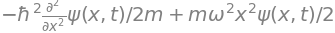

In [3]:
demo["Hamiltonian_Expr"]


In [4]:
comms = qi.commutator_pauli_sympy()
for name, residual in comms.items():
    ok = residual == sp.zeros(2)
    print(f"{name}:  residual = {residual.tolist()}   verified: {ok}")


[X,Y] = 2i*Z:  residual = [[0, 0], [0, 0]]   verified: True
[Y,Z] = 2i*X:  residual = [[0, 0], [0, 0]]   verified: True
[Z,X] = 2i*Y:  residual = [[0, 0], [0, 0]]   verified: True


## Torch Qubit States + Bloch Vector

$|\psi\rangle=\cos(\theta/2)|0\rangle+e^{i\phi}\sin(\theta/2)|1\rangle$,
reimplemented with torch tensors, cross-checked against `qi.qubit_state` /
`qi.bloch_vector` (NumPy) at several points on the Bloch sphere.

In [5]:
def qubit_state_torch(theta, phi):
    theta_t = torch.as_tensor(theta, dtype=torch.float64)
    phi_t = torch.as_tensor(phi, dtype=torch.float64)
    alpha = torch.cos(theta_t / 2).to(CDTYPE)
    beta = (torch.exp(1j * phi_t) * torch.sin(theta_t / 2)).to(CDTYPE)
    return torch.stack([alpha, beta])

def bloch_vector_torch(psi):
    psi = psi / torch.linalg.norm(psi)
    rx = 2 * torch.real(psi[0].conj() * psi[1])
    ry = 2 * torch.imag(psi[0].conj() * psi[1])
    rz = torch.abs(psi[0])**2 - torch.abs(psi[1])**2
    return torch.stack([rx, ry, rz]).real

test_angles = [(0.0, 0.0), (np.pi/2, 0.0), (np.pi/2, np.pi/2), (np.pi/3, np.pi/4), (np.pi, 0.0)]
for theta, phi in test_angles:
    psi_np = qi.qubit_state(theta, phi)
    r_np = qi.bloch_vector(psi_np)
    psi_t = qubit_state_torch(theta, phi)
    r_t = bloch_vector_torch(psi_t).numpy()
    match = np.allclose(r_np, r_t, atol=1e-10)
    checks.append(("bloch_vector", theta, match))
    print(f"theta={theta:.3f} phi={phi:.3f}  numpy r={r_np}  torch r={r_t}  match={match}")


theta=0.000 phi=0.000  numpy r=[0. 0. 1.]  torch r=[0. 0. 1.]  match=True
theta=1.571 phi=0.000  numpy r=[1. 0. 0.]  torch r=[1.00000000e+00 0.00000000e+00 2.22044605e-16]  match=True
theta=1.571 phi=1.571  numpy r=[6.123234e-17 1.000000e+00 0.000000e+00]  torch r=[6.12323400e-17 1.00000000e+00 2.22044605e-16]  match=True
theta=1.047 phi=0.785  numpy r=[0.61237244 0.61237244 0.5       ]  torch r=[0.61237244 0.61237244 0.5       ]  match=True
theta=3.142 phi=0.000  numpy r=[ 1.2246468e-16  0.0000000e+00 -1.0000000e+00]  torch r=[ 1.2246468e-16  0.0000000e+00 -1.0000000e+00]  match=True


## Torch Gates, Cross-Checked Against `qi.GATE_*`

In [6]:
X_t = torch.tensor([[0,1],[1,0]], dtype=CDTYPE)
Y_t = torch.tensor([[0,-1j],[1j,0]], dtype=CDTYPE)
Z_t = torch.tensor([[1,0],[0,-1]], dtype=CDTYPE)
H_t = torch.tensor([[1,1],[1,-1]], dtype=CDTYPE) / torch.sqrt(torch.tensor(2.0, dtype=CDTYPE))
S_t = torch.tensor([[1,0],[0,1j]], dtype=CDTYPE)
T_t = torch.tensor([[1,0],[0,torch.exp(1j*torch.tensor(np.pi/4))]], dtype=CDTYPE)
CNOT_t = torch.tensor([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=CDTYPE)

gate_pairs = [("X", qi.GATE_X, X_t), ("Y", qi.GATE_Y, Y_t), ("Z", qi.GATE_Z, Z_t),
              ("H", qi.GATE_H, H_t), ("S", qi.GATE_S, S_t), ("T", qi.GATE_T, T_t),
              ("CNOT", qi.GATE_CNOT, CNOT_t)]
for name, g_np, g_t in gate_pairs:
    match = np.allclose(g_np, g_t.numpy(), atol=1e-10)
    checks.append(("gate", name, match))
    print(f"{name}: match={match}")

def apply_gate_torch(gate, state):
    result = gate.to(CDTYPE) @ state.to(CDTYPE)
    return result / torch.linalg.norm(result)

psi0 = qubit_state_torch(0.0, 0.0)
psi_plus = apply_gate_torch(H_t, psi0)
print("H|0> =", psi_plus.numpy(), " (expect (1,1)/sqrt2)")


X: match=True
Y: match=True
Z: match=True
H: match=True
S: match=True
T: match=True
CNOT: match=True
H|0> = [0.70710678+0.j 0.70710678+0.j]  (expect (1,1)/sqrt2)


## Bell States via Torch (H then CNOT)

`qi.create_bell_state` reimplemented with `torch.kron` instead of
`np.kron`.

In [7]:
def create_bell_state_torch(which="Phi_plus"):
    ket00 = torch.tensor([1,0,0,0], dtype=CDTYPE)
    HI = torch.kron(H_t, torch.eye(2, dtype=CDTYPE))
    state = HI @ ket00
    state = CNOT_t @ state
    if which == "Phi_minus":
        state = torch.kron(Z_t, torch.eye(2, dtype=CDTYPE)) @ state
    elif which == "Psi_plus":
        state = torch.kron(torch.eye(2, dtype=CDTYPE), X_t) @ state
    elif which == "Psi_minus":
        state = torch.kron(Z_t, X_t) @ state
    elif which != "Phi_plus":
        raise ValueError(f"unknown Bell state {which!r}")
    return state / torch.linalg.norm(state)

for which in ["Phi_plus", "Phi_minus", "Psi_plus", "Psi_minus"]:
    s_np = qi.create_bell_state(which)
    s_t = create_bell_state_torch(which).numpy()
    match = np.allclose(np.abs(s_np), np.abs(s_t), atol=1e-10)   # up to global phase
    checks.append(("bell_state", which, match))
    print(f"{which}: numpy={np.round(s_np,3)}  torch={np.round(s_t,3)}  match(|.|)={match}")


Phi_plus: numpy=[0.707+0.j 0.   +0.j 0.   +0.j 0.707+0.j]  torch=[0.707+0.j 0.   +0.j 0.   +0.j 0.707+0.j]  match(|.|)=True
Phi_minus: numpy=[ 0.707+0.j  0.   +0.j  0.   +0.j -0.707+0.j]  torch=[ 0.707+0.j  0.   +0.j  0.   +0.j -0.707+0.j]  match(|.|)=True
Psi_plus: numpy=[0.   +0.j 0.707+0.j 0.707+0.j 0.   +0.j]  torch=[0.   +0.j 0.707+0.j 0.707+0.j 0.   +0.j]  match(|.|)=True
Psi_minus: numpy=[ 0.   +0.j  0.707+0.j -0.707+0.j  0.   +0.j]  torch=[ 0.   +0.j  0.707+0.j -0.707+0.j  0.   +0.j]  match(|.|)=True


## Density Matrix, Partial Trace, Entanglement Entropy -- Torch

`torch.linalg.eigvalsh` handles complex Hermitian matrices directly (returns
real eigenvalues), and `torch.einsum` does the partial trace exactly like
`np.einsum`.

In [8]:
def density_matrix_torch(psi):
    return torch.outer(psi, psi.conj())

def partial_trace_torch(rho, keep=0, dims=(2,2)):
    d0, d1 = dims
    rho4 = rho.reshape(d0, d1, d0, d1)
    if keep == 0:
        return torch.einsum('iaja->ij', rho4)
    return torch.einsum('aiaj->ij', rho4)

def von_neumann_entropy_torch(rho):
    eigvals = torch.linalg.eigvalsh(rho)
    eigvals = eigvals[eigvals > 1e-12]
    return -torch.sum(eigvals * torch.log2(eigvals)).item()

def entanglement_entropy_torch(psi_2qubit):
    rho = density_matrix_torch(psi_2qubit)
    rho_A = partial_trace_torch(rho, keep=0)
    return von_neumann_entropy_torch(rho_A)

for which in ["Phi_plus", "Phi_minus", "Psi_plus", "Psi_minus"]:
    E_np = qi.entanglement_entropy(qi.create_bell_state(which))
    E_t = entanglement_entropy_torch(create_bell_state_torch(which))
    match = np.isclose(E_np, E_t, atol=1e-8)
    checks.append(("entanglement_entropy", which, match))
    print(f"{which}: numpy E={E_np:.4f}  torch E={E_t:.4f}  match={match}")

# a PRODUCT state (not entangled) should give E=0 both ways
product_state = np.kron(qi.qubit_state(0.7, 0.3), qi.qubit_state(1.1, 0.9))
product_state_t = torch.tensor(product_state, dtype=CDTYPE)
E_np_prod = qi.entanglement_entropy(product_state)
E_t_prod = entanglement_entropy_torch(product_state_t)
print(f"\nproduct state (unentangled): numpy E={E_np_prod:.2e}  torch E={E_t_prod:.2e}  (both ~0)")
checks.append(("entanglement_entropy", "product_state", E_np_prod < 1e-6 and E_t_prod < 1e-6))


Phi_plus: numpy E=1.0000  torch E=1.0000  match=True
Phi_minus: numpy E=1.0000  torch E=1.0000  match=True
Psi_plus: numpy E=1.0000  torch E=1.0000  match=True
Psi_minus: numpy E=1.0000  torch E=1.0000  match=True

product state (unentangled): numpy E=-0.00e+00  torch E=-0.00e+00  (both ~0)


## Quantum Teleportation via Torch

Reimplements `qi.quantum_teleportation_circuit` with torch tensors; checks
that every one of the 4 measurement outcomes gives Bob a state with fidelity
1 to Alice's original (up to the classical corrections), matching the NumPy
version outcome-by-outcome.

In [9]:
def quantum_teleportation_circuit_torch(psi_to_send):
    psi = psi_to_send.to(CDTYPE)
    psi = psi / torch.linalg.norm(psi)
    bell = create_bell_state_torch("Phi_plus")
    state = torch.kron(psi, bell)

    I2 = torch.eye(2, dtype=CDTYPE)
    CNOT_AB = torch.kron(CNOT_t, I2)
    state = CNOT_AB @ state
    H_A = torch.kron(H_t, torch.eye(4, dtype=CDTYPE))
    state = H_A @ state

    outcomes = {}
    state_cube = state.reshape(2, 2, 2)
    for ma in range(2):
        for mb in range(2):
            bob_unnorm = state_cube[ma, mb, :]
            prob = torch.sum(torch.abs(bob_unnorm)**2).item()
            if prob > 1e-12:
                bob = bob_unnorm / np.sqrt(prob)
                if mb == 1:
                    bob = X_t @ bob
                if ma == 1:
                    bob = Z_t @ bob
                outcomes[(ma, mb)] = {"bob_state": bob, "prob": prob}
    return outcomes

psi_alice_np = qi.qubit_state(np.pi/3, np.pi/4)
psi_alice_t = qubit_state_torch(np.pi/3, np.pi/4)

outcomes_np = qi.quantum_teleportation_circuit(psi_alice_np)
outcomes_t = quantum_teleportation_circuit_torch(psi_alice_t)

for key in outcomes_np:
    fid_np = abs(np.vdot(psi_alice_np, outcomes_np[key]["bob_state"]))**2
    fid_t = (torch.abs(torch.vdot(psi_alice_t, outcomes_t[key]["bob_state"]))**2).item()
    match = np.isclose(fid_np, 1.0, atol=1e-8) and np.isclose(fid_t, 1.0, atol=1e-8)
    checks.append(("teleportation_fidelity", str(key), match))
    print(f"outcome {key}: numpy fidelity={fid_np:.6f}  torch fidelity={fid_t:.6f}  P={outcomes_np[key]['prob']:.3f}")


outcome (0, 0): numpy fidelity=1.000000  torch fidelity=1.000000  P=0.250
outcome (0, 1): numpy fidelity=1.000000  torch fidelity=1.000000  P=0.250
outcome (1, 0): numpy fidelity=1.000000  torch fidelity=1.000000  P=0.250
outcome (1, 1): numpy fidelity=1.000000  torch fidelity=1.000000  P=0.250


## Torch-Autograd Bonus: Gradient-Descent Qubit State Preparation

Something the NumPy version simply cannot do: treat $(\theta,\phi)$ as
trainable parameters and gradient-descend them so the prepared state matches
a target state, using `torch.optim.Adam` on the infidelity
$1-|\langle\text{target}|\psi\rangle|^2$. **Fidelity**, not the raw angles, is
the thing that should converge -- $(\theta,\phi)$ has gauge redundancy
(different angle pairs can give the same physical state up to global phase),
so checking angle-for-angle equality would be the wrong test.

In [10]:
target_theta, target_phi = 1.9, 2.3
target = qubit_state_torch(target_theta, target_phi).detach()

theta_param = torch.tensor(0.1, requires_grad=True)
phi_param = torch.tensor(0.1, requires_grad=True)
opt = torch.optim.Adam([theta_param, phi_param], lr=0.1)

history = []
for step in range(300):
    opt.zero_grad()
    psi = qubit_state_torch(theta_param, phi_param)
    fidelity = torch.abs(torch.vdot(target, psi))**2
    loss = 1 - fidelity
    loss.backward()
    opt.step()
    history.append(fidelity.item())

print(f"final fidelity: {history[-1]:.10f}")
print(f"recovered (theta,phi) = ({theta_param.item():.4f}, {phi_param.item():.4f})")
print(f"target    (theta,phi) = ({target_theta:.4f}, {target_phi:.4f})")
print("(angles need not match exactly -- gauge freedom -- fidelity->1 is the real check)")
checks.append(("autograd_state_prep", "fidelity", history[-1] > 1 - 1e-8))


final fidelity: 1.0000000000
recovered (theta,phi) = (-1.9000, -0.8416)
target    (theta,phi) = (1.9000, 2.3000)
(angles need not match exactly -- gauge freedom -- fidelity->1 is the real check)


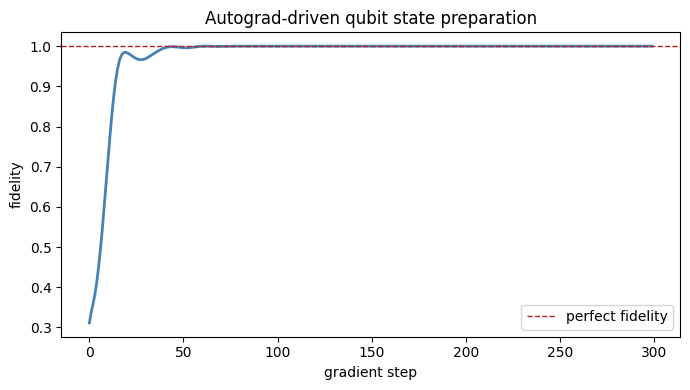

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(history, lw=2, color="steelblue")
ax.axhline(1.0, color="firebrick", ls="--", lw=1, label="perfect fidelity")
ax.set_xlabel("gradient step"); ax.set_ylabel("fidelity")
ax.set_title("Autograd-driven qubit state preparation")
ax.legend()
plt.tight_layout()
plt.savefig("qubit_autograd_fidelity.png", dpi=90)
plt.show()


## Symbolic QI Formalism, Rendered

In [12]:
for name, eq in qi.quantum_information_sympy_5().items():
    print(name)
    display(eq)


Qubit_state


Von_Neumann_entropy


Bell_Phi_plus


Majorana_anticommutator


Chern_number


## Summary: NumPy vs. Torch Agreement

In [13]:
df = pd.DataFrame(checks, columns=["category", "case", "match"])
print(df.to_string(index=False))
assert df["match"].all(), "every numpy/torch cross-check must agree"
print(f"\nAll {len(df)} numpy/torch cross-checks agree, across "
      f"{df['category'].nunique()} categories.")


              category          case  match
          bloch_vector           0.0   True
          bloch_vector      1.570796   True
          bloch_vector      1.570796   True
          bloch_vector      1.047198   True
          bloch_vector      3.141593   True
                  gate             X   True
                  gate             Y   True
                  gate             Z   True
                  gate             H   True
                  gate             S   True
                  gate             T   True
                  gate          CNOT   True
            bell_state      Phi_plus   True
            bell_state     Phi_minus   True
            bell_state      Psi_plus   True
            bell_state     Psi_minus   True
  entanglement_entropy      Phi_plus   True
  entanglement_entropy     Phi_minus   True
  entanglement_entropy      Psi_plus   True
  entanglement_entropy     Psi_minus   True
  entanglement_entropy product_state   True
teleportation_fidelity        (0